In [1]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import grad, random, vmap
import jax

class PrinzEnergy:
    def __init__(self):
        self.dim = 1

    def energy(self, x):
        return 4. * (x ** 8. + 0.8 * jnp.exp(-80. * x ** 2.) +
                     0.2 * jnp.exp(-80. * (x - 0.5) ** 2.) +
                     0.5 * jnp.exp(-40. * (x + 0.5) ** 2.))

class DoubleWell:
    def __init__(self):
        self.dim = 1

    def energy(self, x):
        return 0.25 * (x**2 - 1)**2

class WolfeQuappEnergy:
    def __init__(self):
        self.dim = 2

    def energy(self, x):
        return x[0]**4+x[1]**4-2*x[0]**2-4*x[1]**2+x[0]*x[1]+0.3*x[0]+0.1*x[1]

In [2]:
def overdamped_langevin_step(x, key, energy_fn, dt, kBT):
    force = -grad(energy_fn)(x)
    noise = random.normal(key, shape=x.shape) * jnp.sqrt(2 * kBT * dt)
    x_new = x + force * dt + noise
    return x_new

def run_batched_simulation(initial_positions, energy_fn, num_steps, dt, temperature, key):
    kBT = temperature # thermal unit

    def scan_fn(carry, step_input):
        current_positions, current_key = carry
        sub_key_positions = random.split(current_key, num=current_positions.shape[0] + 1)
        rng_keys = sub_key_positions[1:] # One key for each position
        next_key = sub_key_positions[0]

        # Use vmap to apply the Langevin step to each particle in the batch
        # The step function needs to take a single key for each particle
        vmapped_step = vmap(lambda pos, k: overdamped_langevin_step(pos, k, energy_fn, dt, kBT))
        next_positions = vmapped_step(current_positions, rng_keys)
        return (next_positions, next_key), next_positions

    # Initialize with initial_positions and a random key for the first step
    (final_positions, _), all_positions = jax.lax.scan(scan_fn, (initial_positions, key), None, length=num_steps)

    return all_positions

In [3]:
# Initialize WolfeQuappEnergy
prinz = DoubleWell()
energy_function = prinz.energy

# Simulation parameters
grid_size = 200
x_init_1d = jnp.linspace(-1.0, 1.0, grid_size)
#y_init_1d = jnp.linspace(-2.0, 2.0, grid_size)
#initial_x_grid, initial_y_grid = jnp.meshgrid(x_init_1d, y_init_1d)
# Reshape to (num_batches, dim)
initial_positions = x_init_1d #jnp.stack([initial_x_grid.flatten(), initial_y_grid.flatten()], axis=1) # Shape (grid_size*grid_size, 2)
num_batches = grid_size # Update num_batches based on the grid

num_steps = 100000
dt = 0.001
temperature = 1.0 # Use the system's temperature

# JAX random key
key = random.PRNGKey(0)

# Run the batched simulation
temperatures = [0.1,0.2,0.25,0.3,0.4,0.5,0.75,0.9,1,1.1,1.25,2]
all_sim = {}
for t in temperatures:
    all_simulated_positions = run_batched_simulation(initial_positions, energy_function, num_steps, dt, t, key)
    all_sim[t] = all_simulated_positions


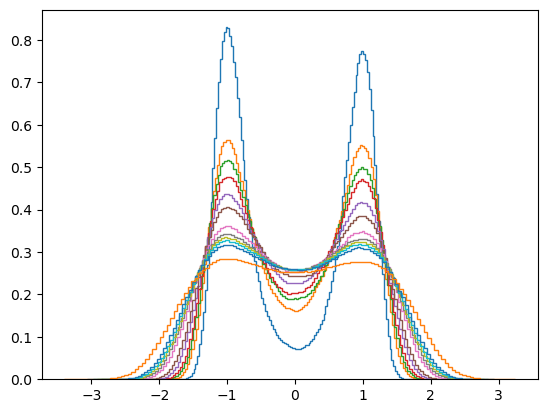

In [4]:
for k in all_sim.keys():
    plt.hist(all_sim[k][10:,:].ravel(),bins=128, histtype='step', density=True);


In [5]:
np.savez("../data/DW.npz", **{str(k):all_sim[k] for k in  all_sim.keys()} )
np.savez("../data/DW_lowT.npz", **{str(k): all_sim[k] for k in [0.1, 0.2, 0.25]})